In [38]:
import pandas as pd

# 读取Excel文件
df = pd.read_excel('D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx')

# 对“工业生产者出厂价格指数”列做一阶差分
df['工业生产者出厂价格指数_差分'] = df['工业生产者出厂价格指数'].diff()

# 保存文件
df.to_excel('D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分.xlsx', index=False)

print("差分处理完成，新列'工业生产者出厂价格指数_差分'已添加到文件中")
print("\n差分结果预览：")
print(df[['month', '工业生产者出厂价格指数', '工业生产者出厂价格指数_差分']].head(10))

差分处理完成，新列'工业生产者出厂价格指数_差分'已添加到文件中

差分结果预览：
     month  工业生产者出厂价格指数  工业生产者出厂价格指数_差分
0  2019-03        100.4             NaN
1  2019-04        100.9             0.5
2  2019-05        100.6            -0.3
3  2019-06        100.0            -0.6
4  2019-07         99.7            -0.3
5  2019-08         99.2            -0.5
6  2019-09         98.8            -0.4
7  2019-10         98.4            -0.4
8  2019-11         98.6             0.2
9  2019-12         99.5             0.9


In [42]:
import pandas as pd

# 读取Excel文件
df = pd.read_excel('D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分.xlsx')

# 对“工业生产者出厂价格指数”列做一阶差分
df['snownlp标题修正_差分'] = df['snownlp标题修正'].diff()
df['snownlp中心化_差分'] = df['snownlp中心化'].diff()
df['svm标题修正_差分'] = df['svm标题修正'].diff()
df['svm中心化_差分'] = df['svm中心化'].diff()

# 保存文件
df.to_excel('D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分2.xlsx', index=False)

print("差分处理完成，新列'工业生产者出厂价格指数_差分'已添加到文件中")
print("\n差分结果预览：")
print(df[['month', '工业生产者出厂价格指数', '工业生产者出厂价格指数_差分']].head(10))

差分处理完成，新列'工业生产者出厂价格指数_差分'已添加到文件中

差分结果预览：
     month  工业生产者出厂价格指数  工业生产者出厂价格指数_差分
0  2019-03        100.4             NaN
1  2019-04        100.9             0.5
2  2019-05        100.6            -0.3
3  2019-06        100.0            -0.6
4  2019-07         99.7            -0.3
5  2019-08         99.2            -0.5
6  2019-09         98.8            -0.4
7  2019-10         98.4            -0.4
8  2019-11         98.6             0.2
9  2019-12         99.5             0.9


In [43]:
import pandas as pd

# 读取Excel文件
df = pd.read_excel('D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分2.xlsx')

# 对“工业生产者出厂价格指数”列做一阶差分
df['HS300_差分'] = df['HS300'].diff()
df['nb中心化_差分'] = df['nb中心化'].diff()
df['nb标题修正_差分'] = df['nb标题修正'].diff()
df['snownlp原始得分_差分'] = df['snownlp原始得分'].diff()

# 保存文件
df.to_excel('D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx', index=False)

print("差分处理完成，新列'工业生产者出厂价格指数_差分'已添加到文件中")
print("\n差分结果预览：")
print(df[['month', '工业生产者出厂价格指数', '工业生产者出厂价格指数_差分']].head(10))

差分处理完成，新列'工业生产者出厂价格指数_差分'已添加到文件中

差分结果预览：
     month  工业生产者出厂价格指数  工业生产者出厂价格指数_差分
0  2019-03        100.4             NaN
1  2019-04        100.9             0.5
2  2019-05        100.6            -0.3
3  2019-06        100.0            -0.6
4  2019-07         99.7            -0.3
5  2019-08         99.2            -0.5
6  2019-09         98.8            -0.4
7  2019-10         98.4            -0.4
8  2019-11         98.6             0.2
9  2019-12         99.5             0.9


相关系数矩阵:
[[1.       0.215583]
 [0.215583 1.      ]]


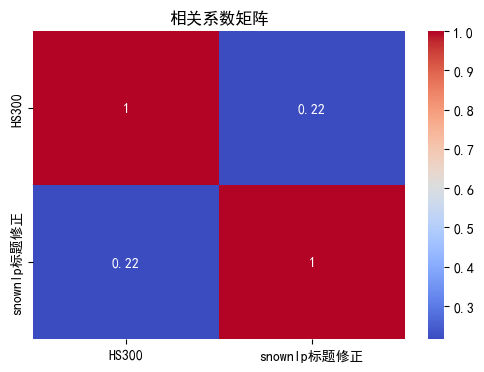

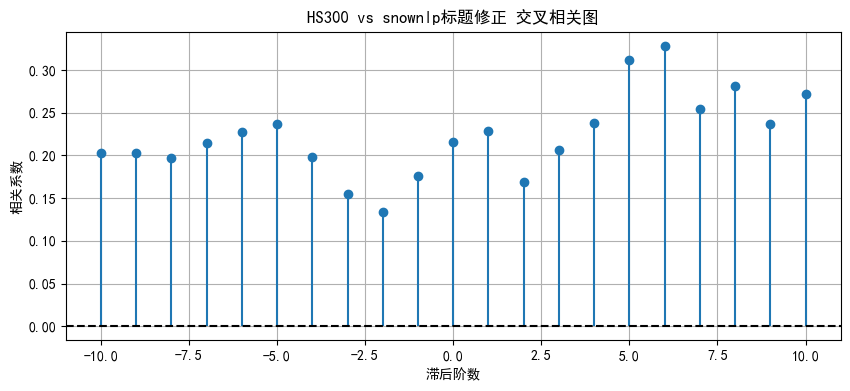

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. 读取数据
file_path = "D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx"
df = pd.read_excel(file_path)

# 2. 提取需要的两列
hs300_diff = df['HS300'].dropna()
snownlp_diff = df['snownlp标题修正'].dropna()

# 确保两个序列长度一致
min_len = min(len(hs300_diff), len(snownlp_diff))
hs300_diff = hs300_diff.iloc[:min_len]
snownlp_diff = snownlp_diff.iloc[:min_len]

# 3. 相关系数矩阵
corr_matrix = np.corrcoef(hs300_diff, snownlp_diff)
print("相关系数矩阵:")
print(corr_matrix)

# 可视化相关系数矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=['HS300', 'snownlp标题修正'],
            yticklabels=['HS300', 'snownlp标题修正'])
plt.title('相关系数矩阵')
plt.show()

# 4. 时间交叉相关
def cross_correlation(x, y, max_lags=10):
    """计算两个序列的交叉相关"""
    correlations = []
    lags = range(-max_lags, max_lags + 1)
    for lag in lags:
        if lag < 0:
            corr = np.corrcoef(x[-lag:], y[:lag])[0, 1]
        elif lag > 0:
            corr = np.corrcoef(x[:-lag], y[lag:])[0, 1]
        else:
            corr = np.corrcoef(x, y)[0, 1]
        correlations.append(corr)
    return lags, correlations

lags, cross_corr = cross_correlation(hs300_diff.values, snownlp_diff.values)

# 绘制交叉相关图
plt.figure(figsize=(10, 4))
plt.stem(lags, cross_corr, basefmt=" ")
plt.axhline(0, color='black', linestyle='--')
plt.title('HS300 vs snownlp标题修正 交叉相关图')
plt.xlabel('滞后阶数')
plt.ylabel('相关系数')
plt.grid(True)
plt.show()


In [47]:
# 5. 协整分析
# 首先进行ADF单位根检验
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    result = adfuller(series)
    print(f'ADF检验结果 - {title}:')
    print(f'ADF统计量: {result[0]}')
    print(f'p值: {result[1]}')
    print('序列是平稳的' if result[1] < 0.05 else '序列是非平稳的')
    print()

# 检验两个序列的平稳性
adf_test(hs300_diff, 'HS300_差分')
adf_test(snownlp_diff, 'snownlp标题修正_差分')

# 进行协整检验
coint_stat, p_value, critical_values = coint(hs300_diff, snownlp_diff)
print("协整检验结果:")
print(f"协整统计量: {coint_stat}")
print(f"p值: {p_value}")
print(f"临界值: {critical_values}")
print('存在协整关系' if p_value < 0.05 else '不存在协整关系')

# 6. 结果总结
print("\n=== 分析结果总结 ===")
print(f"相关系数: {corr_matrix[0, 1]:.4f}")
print(f"最大交叉相关系数: {max(cross_corr, key=abs):.4f} (滞后阶数: {lags[cross_corr.index(max(cross_corr, key=abs))]})")
print(f"协整检验p值: {p_value:.4f}")

ADF检验结果 - HS300_差分:
ADF统计量: -8.81396987798716
p值: 1.9569255618868768e-14
序列是平稳的

ADF检验结果 - snownlp标题修正_差分:
ADF统计量: -7.097692034914533
p值: 4.2470599602080195e-10
序列是平稳的

协整检验结果:
协整统计量: -9.029431342083466
p值: 7.319973492877394e-14
临界值: [-4.0404437  -3.41456629 -3.0985719 ]
存在协整关系

=== 分析结果总结 ===
相关系数: 0.0966
最大交叉相关系数: -0.2716 (滞后阶数: 7)
协整检验p值: 0.0000


In [1]:
import pandas as pd
df=pd.read_excel("D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx")
df.head()

,month,hh原始得分,hh中心化,snownlp原始得分,snownlp中心化,snownlp标题修正,训练snownlp原始得分,训练snownlp中心化,训练snownlp标题修正,svm原始得分,...,工业生产者出厂价格指数_差分,snownlp标题修正_差分,snownlp中心化_差分,svm标题修正_差分,svm中心化_差分,HS300,HS300_差分,nb中心化_差分,nb标题修正_差分,snownlp原始得分_差分
0,2019-03,0.117665,0.552479,0.619773,0.543285,0.595989,0.514771,0.502814,0.521837,0.212270,...,NaN,NaN,NaN,NaN,NaN,3872.34,NaN,NaN,NaN,NaN
1,2019-04,0.092671,0.515563,0.596502,0.515231,0.566479,0.516499,0.501374,0.523711,0.208627,...,0.5,-0.029510,-0.028054,-0.000477,0.046888,3913.21,40.87,-0.000900,0.007708,-0.023271
2,2019-05,0.083202,0.495003,0.618337,0.534403,0.581510,0.557234,0.550040,0.584430,0.258496,...,-0.3,0.015031,0.019172,-0.010753,-0.048183,3629.79,-283.42,0.009840,0.005781,0.021835
3,2019-06,0.098951,0.528319,0.584822,0.501289,0.555155,0.525907,0.475394,0.543584,0.266726,...,-0.6,-0.026355,-0.033114,0.066018,0.128779,3825.59,195.80,0.032691,0.014509,-0.033516
4,2019-07,0.110033,0.534599,0.627119,0.553329,0.585189,0.522839,0.480430,0.528639,0.319192,...,-0.3,0.030033,0.052040,-0.068852,-0.151287,3835.36,9.77,-0.029487,-0.009079,0.042297


In [9]:
from statsmodels.tsa.stattools import ccf
import pandas as pd
import pyecharts.options as opts
from pyecharts.charts import Line
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB


DF = df[(df['month'] >= '2021-07') & (df['month'] <= '2025-11')]
# 计算滞后范围
lags = range(-30, 31)

# 定义要分析的时间序列列名
columns = ['hh中心化', 'snownlp中心化', '训练snownlp中心化', 'svm中心化','nb中心化']

# 创建一个字典来保存每个系列的交叉相关值
ccf_results = {col: [ccf(DF['HS300'], DF[col], adjusted=True)[abs(lag)] if lag >= 0 else ccf(DF[col], DF['HS300'], adjusted=True)[abs(lag)] for lag in lags] for col in columns}

# 初始化 Pyecharts Line 图表
line = Line(init_opts=opts.InitOpts(width="1000px", height="500px"))

# 添加 X 轴数据（即滞后期）
x=list(lags)
line.add_xaxis(xaxis_data=x)

# 为每个时间序列添加 Y 轴数据，并设置是否初始显示
for col, ccf_values in ccf_results.items():
    y=ccf_values
    line.add_yaxis(
        series_name=col,
        y_axis=y,
        label_opts=opts.LabelOpts(is_show=False),  # 隐藏数据点标签
    )

# 设置全局配置项
line.set_global_opts(
    title_opts=opts.TitleOpts(title="Cross Correlation with HS300",pos_left="center"),
    xaxis_opts=opts.AxisOpts(name="Lag",type_='value'),
    yaxis_opts=opts.AxisOpts(name="Cross Correlation"),
    
    tooltip_opts=opts.TooltipOpts(trigger="axis"),
    toolbox_opts=opts.ToolboxOpts(
        pos_left='57%',
        pos_top='5%',
        feature={
            "dataZoom": {"yAxisIndex": "none"},
            "restore": {},
            "saveAsImage": {},
            "brush": opts.ToolBoxFeatureBrushOpts(
                type_=["rect", "lineX", "keep", "clear"]
            ),
            "dataView":{},
            
        }
    ),
    brush_opts=opts.BrushOpts(),  # 启用刷选功能
    legend_opts=opts.LegendOpts(
        type_='scroll',
        orient='horizontal',
        pos_left='center',
        pos_top='bottom',
        selector=True,  # 启用选择器
        selector_position="end",  # 选择器位置在图例尾部
        selector_item_gap=10,  # 选择器按钮之间的间隔
        selector_button_gap=15,  # 选择器按钮与图例组件之间的间隔
    )
)

line.load_javascript()

In [10]:
# 渲染图表
line.render_notebook()

In [6]:
import pandas as pd
df=pd.read_excel("D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx")
DF=df[df['month']>='2021-07']
df1=DF.iloc[:,1:].corr()[['宏观经济景气指数：一致指数','居民消费价格指数','工业生产者出厂价格指数','HS300']]
df1

,宏观经济景气指数：一致指数,居民消费价格指数,工业生产者出厂价格指数,HS300
hh原始得分,-0.258075,0.696979,0.718437,0.349931
hh中心化,-0.268412,0.658288,0.691488,0.310059
snownlp原始得分,-0.031592,0.262289,0.355482,0.216667
snownlp中心化,-0.038350,0.173180,0.254755,0.142860
snownlp标题修正,-0.083775,0.296650,0.357537,0.214357
训练snownlp原始得分,-0.012345,0.551655,0.767560,0.516978
训练snownlp中心化,0.190496,0.358756,0.708247,0.458096
训练snownlp标题修正,0.006533,0.524985,0.758495,0.544964
svm原始得分,0.021684,0.605496,0.852374,0.490375
svm中心化,-0.098028,0.649625,0.711069,0.452692


In [8]:
# 保存文件
df1.to_excel('D:/NJU_WORKPIECE/相关系数表.xlsx', index=False)

In [1]:
import pandas as pd
df=pd.read_excel("D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx")
df.head()

,month,hh原始得分,hh中心化,snownlp原始得分,snownlp中心化,snownlp标题修正,训练snownlp原始得分,训练snownlp中心化,训练snownlp标题修正,svm原始得分,svm中心化,svm标题修正,nb原始得分,nb中心化,nb标题修正,宏观经济景气指数：一致指数,居民消费价格指数,工业生产者出厂价格指数,社会消费品零售总额当期值(亿元),HS300
0,2019-03,0.117665,0.552479,0.619773,0.543285,0.595989,0.514771,0.502814,0.521837,0.212270,0.498225,0.326958,0.035112,0.502668,0.189307,99.45,102.28,100.4,43898.0,3872.34
1,2019-04,0.092671,0.515563,0.596502,0.515231,0.566479,0.516499,0.501374,0.523711,0.208627,0.545113,0.326481,0.027536,0.501769,0.197015,99.18,102.54,100.9,46291.3,3913.21
2,2019-05,0.083202,0.495003,0.618337,0.534403,0.581510,0.557234,0.550040,0.584430,0.258496,0.496930,0.315728,0.045842,0.511609,0.202797,98.80,102.70,100.6,41971.0,3629.79
3,2019-06,0.098951,0.528319,0.584822,0.501289,0.555155,0.525907,0.475394,0.543584,0.266726,0.625709,0.381746,0.052049,0.544299,0.217306,98.46,102.68,100.0,39667.6,3825.59
4,2019-07,0.110033,0.534599,0.627119,0.553329,0.585189,0.522839,0.480430,0.528639,0.319192,0.474423,0.312894,0.064565,0.514812,0.208227,98.29,102.78,99.7,38780.2,3835.36


In [2]:
from statsmodels.tsa.stattools import ccf
import pandas as pd
import pyecharts.options as opts
from pyecharts.charts import Line
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB


DF = df[(df['month'] >= '2019-03') & (df['month'] <= '2025-11')]
# 计算滞后范围
lags = range(-30, 31)

# 定义要分析的时间序列列名
columns = ['hh中心化', 'snownlp中心化', '训练snownlp中心化', 'svm中心化','nb中心化']

# 创建一个字典来保存每个系列的交叉相关值
ccf_results = {col: [ccf(DF['宏观经济景气指数：一致指数'], DF[col], adjusted=True)[abs(lag)] if lag >= 0 else ccf(DF[col], DF['宏观经济景气指数：一致指数'], adjusted=True)[abs(lag)] for lag in lags] for col in columns}

# 初始化 Pyecharts Line 图表
line = Line(init_opts=opts.InitOpts(width="1000px", height="500px"))

# 添加 X 轴数据（即滞后期）
x=list(lags)
line.add_xaxis(xaxis_data=x)

# 为每个时间序列添加 Y 轴数据，并设置是否初始显示
for col, ccf_values in ccf_results.items():
    y=ccf_values
    line.add_yaxis(
        series_name=col,
        y_axis=y,
        label_opts=opts.LabelOpts(is_show=False),  # 隐藏数据点标签
    )

# 设置全局配置项
line.set_global_opts(
    title_opts=opts.TitleOpts(title="Cross Correlation with HS300",pos_left="center"),
    xaxis_opts=opts.AxisOpts(name="Lag",type_='value'),
    yaxis_opts=opts.AxisOpts(name="Cross Correlation"),
    
    tooltip_opts=opts.TooltipOpts(trigger="axis"),
    toolbox_opts=opts.ToolboxOpts(
        pos_left='57%',
        pos_top='5%',
        feature={
            "dataZoom": {"yAxisIndex": "none"},
            "restore": {},
            "saveAsImage": {},
            "brush": opts.ToolBoxFeatureBrushOpts(
                type_=["rect", "lineX", "keep", "clear"]
            ),
            "dataView":{},
            
        }
    ),
    brush_opts=opts.BrushOpts(),  # 启用刷选功能
    legend_opts=opts.LegendOpts(
        type_='scroll',
        orient='horizontal',
        pos_left='center',
        pos_top='bottom',
        selector=True,  # 启用选择器
        selector_position="end",  # 选择器位置在图例尾部
        selector_item_gap=10,  # 选择器按钮之间的间隔
        selector_button_gap=15,  # 选择器按钮与图例组件之间的间隔
    )
)

line.load_javascript()

C:\Anaconda\Lib\site-packages\scipy\signal\_signaltools.py:265: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return convolve(in1, _reverse_and_conj(in2), mode, method)


In [3]:
# 渲染图表
line.render_notebook()